**Скрытая Марковская модель (HMM)**

Скрытая Марковская модель - это вероятностная модель последовательности, которая состоит из набора наблюдаемых переменных X = {x1,...,xN} и скрытых
переменных(переменные состояния) T = {t1 ,...,tN}. Целью модели является как можно точнее смоделировать статические свойства источников сигналов.

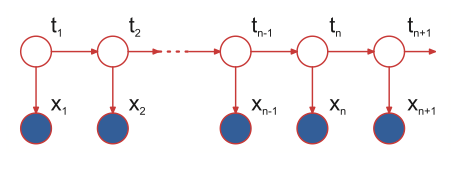

Наблюдаемые переменные - слова

Скрытые переменные - теги

Модель не имеет точной информации о тегах, но знает общие тенденции. Основываясь на том, какие теги были у слов в обучающей выборке, модель пытается угадать, какой тег будет у новых слов.

## Импортируем библиотеки

In [ ]:
import nltk
import random
import numpy as np
import pandas as pd
import pprint, time
from sklearn.model_selection import train_test_split

Для обучения используем материалы Диалог 2017 (General Internet-Corpus of Russian)

## Скачиваем данные

### Либо из google-drive

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

In [ ]:
with open("/content/drive/MyDrive/МСП/gikrya_train.txt") as f:
  data = f.read()

### либо из github

In [ ]:
!wget https://raw.githubusercontent.com/appling2024/data/refs/heads/main/GSD_train.txt
!wget https://raw.githubusercontent.com/appling2024/data/refs/heads/main/GSD_test.txt

--2024-11-08 08:14:38--  https://raw.githubusercontent.com/appling2024/data/refs/heads/main/GSD_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7626752 (7.3M) [text/plain]
Saving to: ‘GSD_train.txt’

GSD_train.txt       100%[===================>]   7.27M  --.-KB/s    in 0.05s   

2024-11-08 08:14:39 (155 MB/s) - ‘GSD_train.txt’ saved [7626752/7626752]

--2024-11-08 08:14:39--  https://raw.githubusercontent.com/appling2024/data/refs/heads/main/GSD_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81386 (79K) [text/

In [ ]:
with open("GSD_train.txt", encoding='utf-8') as f:
  data = f.read()

In [ ]:
sent = data.split('\n\n')

## Анализ данных

Посмотрим, как выглядят наши данные. Выведем первые 3 предложения:

In [ ]:
for i in range(3):
  print(sent[i])
  print('')

1	Начальный	начальный	ADJ	JJL	Case=Nom|Degree=Pos|Gender=Masc|Number=Sing	2	amod	_	_
2	ролик	ролик	NOUN	NN	Animacy=Inan|Case=Nom|Gender=Masc|Number=Sing	17	nsubj	_	SpaceAfter=No
3	,	,	PUNCT	,	_	5	punct	_	_
4	или	или	CCONJ	CC	_	5	cc	_	_
5	опенинг	опенинг	NOUN	NN	Animacy=Inan|Case=Nom|Gender=Masc|Number=Sing	2	conj	_	_
6	(	(	PUNCT	(	_	7	punct	_	SpaceAfter=No
7	от	от	ADP	IN	_	5	parataxis	_	SpaceAfter=No
8	,	,	PUNCT	,	_	11	punct	_	_
9	сокр.	сокращенно	ADV	RB	Degree=Pos	11	advmod	_	SpaceAfter=No
10	:	:	PUNCT	:	_	11	punct	_	_
11	OP	op	X	FW	Foreign=Yes	7	conj	_	SpaceAfter=No
12	)	)	PUNCT	)	_	7	punct	_	SpaceAfter=No
13	,	,	PUNCT	,	_	15	punct	_	_
14	как	как	ADP	IN	_	15	case	_	_
15	правило	правило	NOUN	NN	Animacy=Inan|Case=Nom|Gender=Neut|Number=Sing	17	obl	_	SpaceAfter=No
16	,	,	PUNCT	,	_	15	punct	_	_
17	представляет	представлять	VERB	VBC	Aspect=Imp|Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin|Voice=Act	0	root	_	_
18	собой	себя	PRON	PRP	Case=Ins|Reflex=Yes	17	iobj	_	_
19	анимацию	анима

In [ ]:
for i in sent[-5:]:
  print(i, '\n')

1	В	в	ADP	IN	_	3	case	_	_
2	каждом	каждый	DET	DT	Case=Loc|Gender=Masc|Number=Sing	3	det	_	_
3	месяце	месяц	NOUN	NN	Animacy=Inan|Case=Loc|Gender=Masc|Number=Sing	7	nmod	_	_
4	тоже	тоже	PART	IN	_	7	advmod	_	_
5	по	по	ADP	IN	_	7	case	_	_
6	30	30	NUM	CD	Case=Acc|NumType=Card	7	nummod:gov	_	_
7	дней	день	NOUN	NN	Animacy=Inan|Case=Dat|Gender=Masc|Number=Plur	0	root	_	SpaceAfter=No
8	.	.	PUNCT	.	_	7	punct	_	_ 

1	``	``	PUNCT	``	_	4	punct	_	SpaceAfter=No
2	Адад	Адад	PROPN	NNP	Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing	4	vocative	_	_
3	потомство	потомство	NOUN	NN	Animacy=Inan|Case=Acc|Gender=Neut|Number=Sing	4	obj	_	_
4	храни	хранить	VERB	VBC	Aspect=Imp|Mood=Imp|Number=Sing|Person=2|VerbForm=Fin|Voice=Act	21	parataxis	_	SpaceAfter=No
5	&#39;&#39;	&#39;&#39;	PUNCT	.	_	4	punct	_	SpaceAfter=No
6	;	;	PUNCT	:	_	4	punct	_	_
7	dIM	dIM	X	FW	Foreign=Yes	4	list	_	SpaceAfter=No
8	,	,	PUNCT	,	_	9	punct	_	_
9	MU	mu	X	FW	Foreign=Yes	7	list	_	SpaceAfter=No
10	,	,	PUNCT	,	_	11	punct	_	_
11	ŠEŠ	šeš	X	FW	Fore

In [ ]:
# представляем данные в виде списка, который содержит другие списки, каждый из
# которых соответствует одному предложению и содержит все слова и их теги в виде кортежа (слово, тег)
tokens = []
for sentence in sent:
    s = []
    for word in sentence.split('\n'):
        if word:
            token = (word.split()[1], word.split()[3])
            s.append(token)
    tokens.append(s)

In [ ]:
print(tokens[0:10])

[[('Начальный', 'ADJ'), ('ролик', 'NOUN'), (',', 'PUNCT'), ('или', 'CCONJ'), ('опенинг', 'NOUN'), ('(', 'PUNCT'), ('от', 'ADP'), (',', 'PUNCT'), ('сокр.', 'ADV'), (':', 'PUNCT'), ('OP', 'X'), (')', 'PUNCT'), (',', 'PUNCT'), ('как', 'ADP'), ('правило', 'NOUN'), (',', 'PUNCT'), ('представляет', 'VERB'), ('собой', 'PRON'), ('анимацию', 'NOUN'), (',', 'PUNCT'), ('изображающую', 'VERB'), ('главных', 'ADJ'), ('героев', 'NOUN'), ('аниме', 'NOUN'), ('и', 'CCONJ'), ('отражающую', 'VERB'), ('его', 'DET'), ('стиль', 'NOUN'), ('.', 'PUNCT')], [('Стропило', 'NOUN'), (',', 'PUNCT'), ('означающее', 'VERB'), ('победителя', 'NOUN'), (',', 'PUNCT'), ('окрашено', 'VERB'), ('в', 'ADP'), ('красный', 'ADJ'), ('цвет', 'NOUN'), ('--', 'PUNCT'), ('цвет', 'NOUN'), ('гербового', 'ADJ'), ('щита', 'NOUN'), ('Москвы', 'PROPN'), (',', 'PUNCT'), ('стропило', 'NOUN'), (',', 'PUNCT'), ('означающее', 'VERB'), ('побеждённого', 'VERB'), (',', 'PUNCT'), ('имеет', 'VERB'), ('зелёный', 'ADJ'), ('цвет', 'NOUN'), ('--', 'PUNCT

In [ ]:
# смотрим сколько всего у нас предложений
print(len(sent))

4975


## Подготовка к обучению HMM

In [ ]:
# делим даннные на обучающую и тестовую выборки в соотношении 80:20
# данные выбираются рандомно, random_state - фиксирует набор
train_set,test_set =train_test_split(tokens, train_size=0.80, test_size=0.20, random_state = 101)

In [ ]:
print(len(train_set))
print(len(test_set))

3980
995


In [ ]:
# из списка списков создаем список размеченных обучающих и тестовых данных
train_tagged_words = [ tup for sent in train_set for tup in sent ]
test_tagged_words = [ tup for sent in test_set for tup in sent ]
print(len(train_tagged_words))
print(len(test_tagged_words))

77589
19372


In [ ]:
# проверяем первые 7 размеченных слов в обучающей выборке
train_tagged_words[:7]

[('Реакция', 'NOUN'),
 ('Мексиканской', 'ADJ'),
 ('биржи', 'NOUN'),
 ('на', 'ADP'),
 ('эти', 'DET'),
 ('изменения', 'NOUN'),
 (',', 'PUNCT')]

In [ ]:
# смотрим сколько уникальных тегов присутствует в обучающей выборке
tags = {tag for word, tag in train_tagged_words}
print('Количество уникальных тегов:', len(tags))
print('Набор тегов:', tags)

Количество уникальных тегов: 16
Набор тегов: {'SYM', 'PUNCT', 'ADJ', 'CCONJ', 'SCONJ', 'ADP', 'NOUN', 'ADV', 'AUX', 'NUM', 'PRON', 'PART', 'VERB', 'X', 'DET', 'PROPN'}


In [ ]:
# проверяем количество уникальных словоупотреблений
vocab = {word for word,tag in train_tagged_words}
print('Количество уникальных словоупотреблений:', len(vocab))

Количество уникальных словоупотреблений: 26465


## Принцип обучения HMM

Для каждого состояния скрытой марковской модели задан вектор вероятности эмиссии(выбросов), который характеризует вероятность наблюдения каждого события, когда модель находится в этом состоянии.

В нашем случае эмиссия - "насколько вероятно, что конкретное слово будет иметь конкретный тег".

Совокупность таких векторов образует матрицу эмиссии.

In [ ]:
# рассчитываем вероятности эмиссии
# они определяют вероятность увидеть определенную наблюдаемую переменную при заданном значении для скрытых переменных,
# т.е. эта функция возвращает то, сколько всего раз тег встречался в выборке и сколько раз определенное слово встречалось с этим тегом
def word_given_tag(word, tag, train_bag=train_tagged_words):
    tag_list = [pair for pair in train_bag if pair[1]==tag] # список всех слов определенного тега
    count_tag = len(tag_list)# общее число появления тегов в обучающей выборке
    w_given_tag_list = [pair[0] for pair in tag_list if pair[0]==word] # cписок, который состоит из всех вхождений данного слова, которые были помечены определенным тегом
    count_w_given_tag = len(w_given_tag_list) # подсчитываем общее количество раз, когда слово встречалось с тегом

    return (count_w_given_tag, count_tag)

[**Вероятность перехода**](http://stratum.ac.ru/education/textbooks/modelir/lection33.html)

Модель марковского процесса представим в виде графа, в котором состояния (вершины) связаны между собой связями (переходами из i-го состояния в j-е состояние)

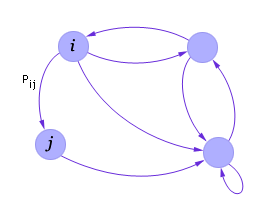

Каждый переход характеризуется вероятностью перехода Pij. Вероятность Pij показывает, как часто после попадания в i-е состояние осуществляется затем переход в j-е состояние.

Таким образом, реализация марковского процесса представляет собой вычисление последовательности (цепи) переходов из состояния в состояние.
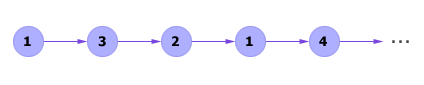



In [ ]:
# рассчитаем вероятность переходов
def t2_given_t1(t2, t1, train_bag=train_tagged_words): # t1 = t2, это пронумерованный список тегов
    tags = [pair[1] for pair in train_bag] # список всех тегов по порядку (просто из общего спсика размеченных слов мы убираем слова, получаем последовательность тегов)
    count_t1 = len([t for t in tags if t==t1])
    count_t2_t1 = 0
    for index in range(len(tags)-1):
        if tags[index]==t1 and tags[index+1] == t2: # если при теге t1 следующий тег = t2, то осуществляется переход
            count_t2_t1 += 1
    return (count_t2_t1, count_t1) # сколько всего раз встречается данный (второе значение), сколько раз данный тег переходит в другой тег (первое значение)

In [ ]:
# создаем матрицу тегов t x t, где t - номер тега
# матрица(i, j) представляет вероятность перехода P(i-й тег переходит в j-й тег)

tags_matrix = np.zeros((len(tags), len(tags)), dtype='float32')
for i, t1 in enumerate(list(tags)):
    for j, t2 in enumerate(list(tags)):
        tags_matrix[i, j] = t2_given_t1(t2, t1)[0]/t2_given_t1(t2, t1)[1]

print(tags_matrix)

[[4.16666679e-02 1.80555552e-01 7.63888881e-02 6.94444450e-03
  0.00000000e+00 8.33333358e-02 2.63888896e-01 0.00000000e+00
  0.00000000e+00 1.31944448e-01 6.94444450e-03 0.00000000e+00
  9.02777761e-02 9.02777761e-02 6.94444450e-03 2.08333340e-02]
 [1.12084066e-03 1.18248686e-01 1.24273203e-01 5.16287200e-02
  2.71103326e-02 1.51523650e-01 1.65814355e-01 4.73555177e-02
  5.18388813e-03 2.93520149e-02 3.46059538e-02 9.45709273e-03
  9.91943926e-02 2.71803848e-02 1.34500880e-02 9.44308266e-02]
 [2.06206823e-04 8.56789351e-02 8.56789351e-02 2.19610278e-02
  1.03103412e-04 2.34044753e-02 7.36364603e-01 2.68068863e-03
  2.98999902e-03 1.95896486e-03 1.54655124e-03 2.26827501e-03
  1.26817198e-02 9.27930698e-04 2.16517178e-03 1.93834417e-02]
 [1.24843942e-03 3.37078646e-02 1.77694544e-01 2.78818142e-02
  5.82605088e-03 1.01955891e-01 2.57178515e-01 6.15896806e-02
  7.07449019e-03 2.62172278e-02 1.99750308e-02 2.70495210e-02
  1.31086141e-01 1.12359552e-02 2.45526433e-02 8.57261792e-02]
 [0.

**Матрица перехода тегов(состояний)**

Матрица задает вероятность перехода из каждого тега в каждый.

Наглядно модель марковского процесса можно представить себе в виде следующего графа:
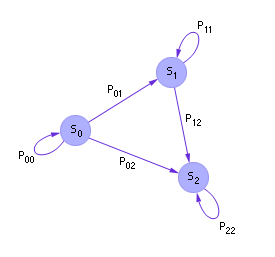


In [ ]:
tags_df = pd.DataFrame(tags_matrix, columns = list(tags), index=list(tags))
display(tags_df)

,SYM,PUNCT,ADJ,CCONJ,SCONJ,ADP,NOUN,ADV,AUX,NUM,PRON,PART,VERB,X,DET,PROPN
SYM,0.041667,0.180556,0.076389,0.006944,0.000000,0.083333,0.263889,0.000000,0.000000,0.131944,0.006944,0.000000,0.090278,0.090278,0.006944,0.020833
PUNCT,0.001121,0.118249,0.124273,0.051629,0.027110,0.151524,0.165814,0.047356,0.005184,0.029352,0.034606,0.009457,0.099194,0.027180,0.013450,0.094431
ADJ,0.000206,0.085679,0.085679,0.021961,0.000103,0.023404,0.736365,0.002681,0.002990,0.001959,0.001547,0.002268,0.012682,0.000928,0.002165,0.019383
CCONJ,0.001248,0.033708,0.177695,0.027882,0.005826,0.101956,0.257179,0.061590,0.007074,0.026217,0.019975,0.027050,0.131086,0.011236,0.024553,0.085726
SCONJ,0.000000,0.024499,0.102450,0.011136,0.026726,0.133630,0.204900,0.066815,0.006682,0.013363,0.097996,0.053452,0.160356,0.004454,0.035635,0.057906
ADP,0.000352,0.011632,0.268124,0.000117,0.000117,0.000705,0.459993,0.005875,0.000000,0.046411,0.053930,0.001527,0.006110,0.005757,0.052520,0.086829
NOUN,0.001319,0.334040,0.111331,0.042196,0.000188,0.128662,0.151549,0.012386,0.011962,0.012904,0.007676,0.006640,0.083969,0.009325,0.010172,0.075681
ADV,0.000562,0.116985,0.128234,0.021372,0.006187,0.165354,0.061867,0.048931,0.013498,0.032621,0.036558,0.048931,0.288526,0.003375,0.013498,0.013498
AUX,0.000000,0.007899,0.110585,0.004739,0.000000,0.017378,0.082148,0.061611,0.004739,0.011058,0.003160,0.022117,0.660348,0.001580,0.006319,0.006319
NUM,0.042067,0.179087,0.093750,0.016827,0.000000,0.067308,0.549880,0.001202,0.003005,0.013822,0.000601,0.003005,0.015024,0.006010,0.004207,0.004207


## Алгоритм Витерби

Алгоритм поиска наиболее подходящего списка состояний, который в контексте цепей Маркова получает наиболее вероятную последовательность скрытых состояний с учётом наблюдающейся последовательности в модели.

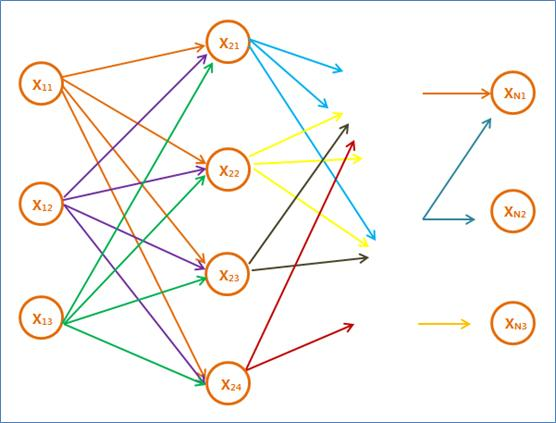

In [ ]:
print(train_tagged_words[0:10])

[('Реакция', 'NOUN'), ('Мексиканской', 'ADJ'), ('биржи', 'NOUN'), ('на', 'ADP'), ('эти', 'DET'), ('изменения', 'NOUN'), (',', 'PUNCT'), ('привела', 'VERB'), ('её', 'PRON'), ('на', 'ADP')]


In [ ]:
def Viterbi(words, train_bag=train_tagged_words): # первый аргумент - список слов, которым нам нужно присвоить тег, второй - размеченная обучающая выборка
    state = []
    T = list(set([pair[1] for pair in train_bag])) # список всех возможных тегов

    for key, word in enumerate(words): # пронумеровываем список слов, чтобы можно было смотреть на предыдущее
        p = [] # инициализируем список столбцов вероятности для каждого наблюдения
        for tag in T: # считаем вероятность перехода
            if key == 0: # если предыдущего тега нет, то рассматриваем вероятность появления слова после знака препинания, в начале предложения
                transition_p = tags_df.loc['PUNCT', tag]
            else: # если предыдущий тег есть, то рассматриваем его
                transition_p = tags_df.loc[state[-1], tag]

            # вычисляем вероятности выбросов и состояний
            emission_p = word_given_tag(words[key], tag)[0]/word_given_tag(words[key], tag)[1] # вероятность выбросов ( насколько вероятно, что конкретное слово будет иметь конкретный тег)
            state_probability = emission_p * transition_p  # вероятность состояний (умножаем веротность того, что слово в принципе встречалось с этим тегом на вероятность перехода)
            p.append(state_probability)


        pmax = max(p) # выбираем максимальное значение из полученного списка
        # получаем наиболее вероятную последовательность скрытых состояний
        state_max = T[p.index(pmax)] # записываем его индекс и находим его соответствие в списке тегов
        state.append(state_max)
    return list(zip(words, state))

In [ ]:
# протестируем алгоритм Витерби на нескольких примерах предложений тестового набора данных
random.seed(1234)      #определяем случайное значение

# выбираем случайные 10 значений
rndom = [random.randint(1,len(test_set)) for x in range(10)]

# список из 10 предложений, на которых мы тестируем модель
test_run = [test_set[i] for i in rndom]

# список размеченных слов
test_run_base = [tup for sent in test_run for tup in sent]

# список неразмеченных слов
test_tagged_words = [tup[0] for sent in test_run for tup in sent]

In [ ]:
print(len(test_tagged_words))
print(test_run_base)
print(test_tagged_words)

147
[('Двери', 'NOUN'), ('из', 'ADP'), ('вагонов', 'NOUN'), ('поезда', 'NOUN'), ('не', 'PART'), ('открываются', 'VERB'), ('.', 'PUNCT'), ('Назвав', 'VERB'), ('призванную', 'VERB'), ('девушку', 'NOUN'), ('в', 'ADP'), ('честь', 'NOUN'), ('своего', 'DET'), ('кота', 'NOUN'), ('``', 'PUNCT'), ('Танарот', 'PROPN'), ('&#39;&#39;', 'PUNCT'), (',', 'PUNCT'), ('он', 'PRON'), ('тем', 'PRON'), ('самым', 'ADJ'), ('заключает', 'VERB'), ('с', 'ADP'), ('ней', 'PRON'), ('контракт', 'NOUN'), ('хозяина', 'NOUN'), ('и', 'CCONJ'), ('слуги', 'NOUN'), ('.', 'PUNCT'), ('Председатель', 'NOUN'), ('Социал-демократической', 'ADJ'), ('партии', 'NOUN'), ('Боснии', 'PROPN'), ('и', 'CCONJ'), ('Герцеговины', 'PROPN'), ('.', 'PUNCT'), ('Телефонный', 'ADJ'), ('код', 'NOUN'), ('--', 'PUNCT'), ('4739', 'NUM'), ('.', 'PUNCT'), ('В', 'ADP'), ('1942', 'ADJ'), ('году', 'NOUN'), ('был', 'AUX'), ('фактически', 'ADV'), ('заключён', 'VERB'), ('под', 'ADP'), ('домашний', 'ADJ'), ('арест', 'NOUN'), ('.', 'PUNCT'), ('Начиная', 'VERB

### Проверяем скорость и точность алгоритма

In [ ]:
start = time.time()
tagged_seq = Viterbi(test_tagged_words)
end = time.time() # считаем сколько времени это заняло
difference = end-start

print("Время в секундах: ", difference)

# проходим по парам (разметка_HMM, разметка_эталон) и если совпали, сохраняем в список
# по существу, нам просто нужно получить количество совпадений
check = [i for i, j in zip(tagged_seq, test_run_base) if i == j]

accuracy = len(check)/len(tagged_seq) # считаем точность
print('Точность алгоритма Витерби, %: ',accuracy*100)

Время в секундах:  37.12158226966858
Точность алгоритма Витерби, %:  63.26530612244898


## Ручная проверка

In [ ]:
# Сравним глазами нашу и эталонную разметку
for our, reference in list(zip(tagged_seq, test_run_base))[:12]:
  print('Наша: {0:20}\tЭталон: {1:20}'.format(str(our), str(reference)))

Наша: ('Двери', 'SYM')    	Эталон: ('Двери', 'NOUN')   
Наша: ('из', 'ADP')       	Эталон: ('из', 'ADP')       
Наша: ('вагонов', 'NOUN') 	Эталон: ('вагонов', 'NOUN') 
Наша: ('поезда', 'NOUN')  	Эталон: ('поезда', 'NOUN')  
Наша: ('не', 'PART')      	Эталон: ('не', 'PART')      
Наша: ('открываются', 'SYM')	Эталон: ('открываются', 'VERB')
Наша: ('.', 'PUNCT')      	Эталон: ('.', 'PUNCT')      
Наша: ('Назвав', 'SYM')   	Эталон: ('Назвав', 'VERB')  
Наша: ('призванную', 'SYM')	Эталон: ('призванную', 'VERB')
Наша: ('девушку', 'NOUN') 	Эталон: ('девушку', 'NOUN') 
Наша: ('в', 'ADP')        	Эталон: ('в', 'ADP')        
Наша: ('честь', 'NOUN')   	Эталон: ('честь', 'NOUN')   


## Автоматическая проверка

In [28]:
# test_run_base =     [tup       for sent in test_run for tup in sent]
with_sent_numbers = [(i, *tup) for i, sent in enumerate(test_run) for tup in sent]
with_sent_numbers


kwiks = []
for sent_i, tk, pos in with_sent_numbers:
    current_sentence = [tk for sent_j, tk, pos in with_sent_numbers if sent_j==sent_i]
    tk_index_in_sent = current_sentence.index(tk)
    kwik = current_sentence[max(0, tk_index_in_sent-3):min(len(sent)+1, tk_index_in_sent+4)]
    kwiks.append((tk, pos, ' '.join(current_sentence), ' '.join(kwik)))


mismatches = []
for our, reference in zip (tagged_seq, kwiks):
    # print(our, reference)
    if our[1] != reference[1]:
        mismatches.append((our[0], our[1], *reference[1:]))
mismatches_df = pd.DataFrame(mismatches, columns=['Слово', 'Наша разметка', 'Эталонная разметка', 'SENT_CONTEXT', '3_WIK'])
mismatches_df.index = range(1, len(mismatches_df) + 1)
mismatches_df.to_excel('Mismatches.xlsx', index=False)
display(mismatches_df)

,Слово,Наша разметка,Эталонная разметка,SENT_CONTEXT,3_WIK
1,Двери,SYM,NOUN,Двери из вагонов поезда не открываются .,Двери из вагонов поезда
2,открываются,SYM,VERB,Двери из вагонов поезда не открываются .,вагонов поезда не открываются .
3,Назвав,SYM,VERB,Назвав призванную девушку в честь своего кота ...,Назвав призванную девушку в
4,призванную,SYM,VERB,Назвав призванную девушку в честь своего кота ...,Назвав призванную девушку в честь
5,кота,SYM,NOUN,Назвав призванную девушку в честь своего кота ...,в честь своего кота `` Танарот &#39;&#39;
6,Танарот,SYM,PROPN,Назвав призванную девушку в честь своего кота ...,"своего кота `` Танарот &#39;&#39; , он"
7,хозяина,SYM,NOUN,Назвав призванную девушку в честь своего кота ...,с ней контракт хозяина и слуги .
8,слуги,SYM,NOUN,Назвав призванную девушку в честь своего кота ...,контракт хозяина и слуги .
9,Социал-демократической,SYM,ADJ,Председатель Социал-демократической партии Бос...,Председатель Социал-демократической партии Бос...
10,Боснии,SYM,PROPN,Председатель Социал-демократической партии Бос...,Председатель Социал-демократической партии Бос...


## Источники:

1. A Guide to Hidden Markov Model and its Applications in NLP (https://analyticsindiamag.com/a-guide-to-hidden-markov-model-and-its-applications-in-nlp/)

2. Датасет: General Internet-Corpus of Russian (https://github.com/dialogue-evaluation/morphoRuEval-2017/blob/master/Baseline.zip)